# Predicting Bank Term Deposit Subscription with Machine Learning

## Project Overview

This project develops a machine learning classification framework to predict whether a bank customer will subscribe to a term deposit.

The analysis uses the Bank Marketing dataset from the UCI Machine Learning Repository and compares two classification approaches:

- Logistic Regression as an interpretable baseline model
- Random Forest as a nonlinear machine learning model

The project focuses not only on predictive performance, but also on realistic model deployment. In particular, the call duration variable is excluded from the final prediction model because it is unavailable before a marketing call takes place and would therefore introduce data leakage.

Because the target variable is highly imbalanced, model performance is evaluated using multiple metrics, including precision, recall, F1-score, and ROC-AUC rather than accuracy alone.

A validation set is used for classification-threshold selection, while the test set is reserved exclusively for final model evaluation.

## Business Question

Can customer characteristics and historical marketing information be used to identify customers who are more likely to subscribe to a term deposit before a marketing call is made?

## Data Source

The analysis uses the **Bank Marketing** dataset from the UCI Machine Learning Repository. The dataset contains information from direct marketing campaigns conducted by a Portuguese banking institution.

The full dataset contains **45,211 observations and 17 variables**, including customer characteristics, financial attributes, previous marketing interactions, and the final subscription outcome.

The target variable is `y`, which indicates whether a customer subscribed to a term deposit (`yes` or `no`).

**Source:** UCI Machine Learning Repository — Bank Marketing Dataset

In [5]:
# ============================================================
# Environment Setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

# Reproducibility
RANDOM_STATE = 42

print("Environment setup completed.")

Environment setup completed.


In [6]:
# ============================================================
# Download and Extract the UCI Bank Marketing Dataset
# ============================================================

# Download the dataset package from the UCI Machine Learning Repository
!wget -q -O bank_marketing.zip https://archive.ics.uci.edu/static/public/222/bank+marketing.zip

# Extract the outer archive
!unzip -oq bank_marketing.zip

# Extract the full Bank Marketing dataset from the nested archive
!mkdir -p bank
!unzip -oq bank.zip -d bank

# Verify that the required dataset file is available
!test -f bank/bank-full.csv && echo "Dataset ready: bank/bank-full.csv"

print("Dataset download and extraction completed successfully.")

Dataset ready: bank/bank-full.csv
Dataset download and extraction completed successfully.


In [7]:
# ============================================================
# Load Dataset and Initial Inspection
# ============================================================

# Load the full Bank Marketing dataset
df = pd.read_csv(
    "bank/bank-full.csv",
    sep=";"
)

print("Dataset loaded successfully!")
print("-" * 50)

# Dataset dimensions
print(f"Number of observations: {df.shape[0]:,}")
print(f"Number of variables: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nTarget distribution:")
print(df["y"].value_counts())

print("\nTarget distribution (%):")
print((df["y"].value_counts(normalize=True) * 100).round(2))

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 observations:")
display(df.head())

Dataset loaded successfully!
--------------------------------------------------
Number of observations: 45,211
Number of variables: 17

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Target distribution (%):
y
no     88.3
yes    11.7
Name: proportion, dtype: float64

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

First 5 observations:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [8]:
# ============================================================
# Load Dataset and Initial Inspection
# ============================================================

# Load the full Bank Marketing dataset
df = pd.read_csv(
    "bank/bank-full.csv",
    sep=";"
)

print("Dataset loaded successfully!")
print("-" * 50)

# Dataset dimensions
print(f"Number of observations: {df.shape[0]:,}")
print(f"Number of variables: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

# Target distribution
print("\nTarget distribution:")
print(df["y"].value_counts())

print("\nTarget distribution (%):")
print((df["y"].value_counts(normalize=True) * 100).round(2))

# Missing values
print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nFirst 5 observations:")
display(df.head())

Dataset loaded successfully!
--------------------------------------------------
Number of observations: 45,211
Number of variables: 17

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Target distribution (%):
y
no     88.3
yes    11.7
Name: proportion, dtype: float64

Total missing values:
0

First 5 observations:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [9]:
# ============================================================
# Data Quality and Leakage Check
# ============================================================

# Check duplicate observations
duplicates = df.duplicated().sum()

print("DATA QUALITY CHECK")
print("-" * 50)
print(f"Duplicate observations: {duplicates}")
print(f"Missing values: {df.isnull().sum().sum()}")

# Check data types
print("\nVariable types:")
print(df.dtypes)

# Inspect categorical variables
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("\nCategorical variables and unique values:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

# ------------------------------------------------------------
# Data Leakage Prevention
# ------------------------------------------------------------

print("\n" + "=" * 50)
print("DATA LEAKAGE CHECK")
print("=" * 50)

print(
    "The 'duration' variable records the duration of the current "
    "marketing call and is only known after the call occurs."
)

print(
    "Because the objective is to predict subscription probability "
    "before making the call, 'duration' is excluded from the model."
)

# Create modeling dataset without duration
df_model = df.drop(columns=["duration"]).copy()

print("\nOriginal dataset shape:", df.shape)
print("Modeling dataset shape:", df_model.shape)

print("\nVariables used for modeling:")
print(df_model.columns.tolist())

DATA QUALITY CHECK
--------------------------------------------------
Duplicate observations: 0
Missing values: 0

Variable types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Categorical variables and unique values:
job: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
marital: ['married' 'single' 'divorced']
education: ['tertiary' 'secondary' 'unknown' 'primary']
default: ['no' 'yes']
housing: ['yes' 'no']
loan: ['no' 'yes']
contact: ['unknown' 'cellular' 'telephone']
month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
poutcome: ['unknown' 'failure' 'o

In [10]:
# ============================================================
# Train / Validation / Test Split
# ============================================================

# Separate predictors and target
X = df_model.drop(columns=["y"])
y = df_model["y"].map({"no": 0, "yes": 1})

# First split: 60% training, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE
)

# Second split: temporary set -> 20% validation + 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("DATA SPLIT SUMMARY")
print("-" * 50)

print(f"Training set:   {len(X_train):,} observations")
print(f"Validation set: {len(X_val):,} observations")
print(f"Test set:       {len(X_test):,} observations")

print("\nPositive class rate:")
print(f"Training:   {y_train.mean():.2%}")
print(f"Validation: {y_val.mean():.2%}")
print(f"Test:       {y_test.mean():.2%}")

print("\nPredictor count:", X_train.shape[1])

# Verify that duration is not included
print("Duration included:", "duration" in X_train.columns)

DATA SPLIT SUMMARY
--------------------------------------------------
Training set:   27,126 observations
Validation set: 9,042 observations
Test set:       9,043 observations

Positive class rate:
Training:   11.70%
Validation: 11.70%
Test:       11.70%

Predictor count: 15
Duration included: False


In [11]:
# ============================================================
# Preprocessing Pipeline
# ============================================================

# Identify numerical and categorical predictors
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("PREPROCESSING SETUP")
print("-" * 50)

print(f"Numerical features ({len(numeric_features)}):")
print(numeric_features)

print(f"\nCategorical features ({len(categorical_features)}):")
print(categorical_features)

# Numerical preprocessing:
# Standardize numerical variables for Logistic Regression
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing:
# Convert categorical variables into one-hot encoded features
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing pipeline created successfully!")
print(f"Total original predictors: {X_train.shape[1]}")

PREPROCESSING SETUP
--------------------------------------------------
Numerical features (6):
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Categorical features (9):
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Preprocessing pipeline created successfully!
Total original predictors: 15


In [12]:
# ============================================================
# Logistic Regression Baseline
# ============================================================

# Build Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

# Predict probabilities on validation set
y_val_prob_lr = logistic_model.predict_proba(X_val)[:, 1]

# Default classification threshold = 0.50
y_val_pred_lr = (y_val_prob_lr >= 0.50).astype(int)

# Calculate evaluation metrics
lr_accuracy = accuracy_score(y_val, y_val_pred_lr)
lr_precision = precision_score(y_val, y_val_pred_lr, zero_division=0)
lr_recall = recall_score(y_val, y_val_pred_lr, zero_division=0)
lr_f1 = f1_score(y_val, y_val_pred_lr, zero_division=0)
lr_auc = roc_auc_score(y_val, y_val_prob_lr)

print("LOGISTIC REGRESSION — VALIDATION RESULTS")
print("-" * 55)

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_lr,
        target_names=["No Subscription", "Subscription"],
        digits=4
    )
)

LOGISTIC REGRESSION — VALIDATION RESULTS
-------------------------------------------------------
Accuracy:  0.8938
Precision: 0.6856
Recall:    0.1711
F1-score:  0.2738
ROC-AUC:   0.7643

Classification Report:
                 precision    recall  f1-score   support

No Subscription     0.9001    0.9896    0.9427      7984
   Subscription     0.6856    0.1711    0.2738      1058

       accuracy                         0.8938      9042
      macro avg     0.7928    0.5803    0.6083      9042
   weighted avg     0.8750    0.8938    0.8645      9042



In [13]:
# ============================================================
# Logistic Regression — Threshold Optimization
# ============================================================

# Precision-recall curve on validation set
precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_val,
    y_val_prob_lr
)

# precision_recall_curve returns one extra precision/recall value
precision_vals = precision_vals[:-1]
recall_vals = recall_vals[:-1]

# Calculate F1 score for each threshold
f1_vals = (
    2 * precision_vals * recall_vals /
    (precision_vals + recall_vals + 1e-10)
)

# Find threshold with highest F1 score
best_idx = np.argmax(f1_vals)

best_threshold_lr = thresholds[best_idx]
best_precision_lr = precision_vals[best_idx]
best_recall_lr = recall_vals[best_idx]
best_f1_lr = f1_vals[best_idx]

print("LOGISTIC REGRESSION — THRESHOLD OPTIMIZATION")
print("-" * 60)

print(f"Default threshold: 0.5000")
print(f"Optimal threshold: {best_threshold_lr:.4f}")

print("\nValidation performance at optimal threshold:")
print(f"Precision: {best_precision_lr:.4f}")
print(f"Recall:    {best_recall_lr:.4f}")
print(f"F1-score:  {best_f1_lr:.4f}")
print(f"ROC-AUC:   {lr_auc:.4f}")

# Compare with default threshold
print("\nComparison:")
print(f"{'Metric':<12} {'Threshold 0.50':>16} {'Optimized':>14}")
print("-" * 44)
print(f"{'Precision':<12} {lr_precision:>16.4f} {best_precision_lr:>14.4f}")
print(f"{'Recall':<12} {lr_recall:>16.4f} {best_recall_lr:>14.4f}")
print(f"{'F1-score':<12} {lr_f1:>16.4f} {best_f1_lr:>14.4f}")

LOGISTIC REGRESSION — THRESHOLD OPTIMIZATION
------------------------------------------------------------
Default threshold: 0.5000
Optimal threshold: 0.2061

Validation performance at optimal threshold:
Precision: 0.4675
Recall:    0.4282
F1-score:  0.4470
ROC-AUC:   0.7643

Comparison:
Metric         Threshold 0.50      Optimized
--------------------------------------------
Precision              0.6856         0.4675
Recall                 0.1711         0.4282
F1-score               0.2738         0.4470


In [14]:
# ============================================================
# Random Forest Baseline
# ============================================================

# Build Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Predict probabilities on validation set
y_val_prob_rf = random_forest_model.predict_proba(X_val)[:, 1]

# Default classification threshold = 0.50
y_val_pred_rf = (y_val_prob_rf >= 0.50).astype(int)

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_val, y_val_pred_rf)
rf_precision = precision_score(y_val, y_val_pred_rf, zero_division=0)
rf_recall = recall_score(y_val, y_val_pred_rf, zero_division=0)
rf_f1 = f1_score(y_val, y_val_pred_rf, zero_division=0)
rf_auc = roc_auc_score(y_val, y_val_prob_rf)

print("RANDOM FOREST — VALIDATION RESULTS")
print("-" * 55)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_rf,
        target_names=["No Subscription", "Subscription"],
        digits=4
    )
)

RANDOM FOREST — VALIDATION RESULTS
-------------------------------------------------------
Accuracy:  0.8933
Precision: 0.6566
Recall:    0.1843
F1-score:  0.2878
ROC-AUC:   0.7813

Classification Report:
                 precision    recall  f1-score   support

No Subscription     0.9013    0.9872    0.9423      7984
   Subscription     0.6566    0.1843    0.2878      1058

       accuracy                         0.8933      9042
      macro avg     0.7789    0.5858    0.6151      9042
   weighted avg     0.8727    0.8933    0.8657      9042



In [15]:
# ============================================================
# Random Forest — Threshold Optimization
# ============================================================

# Precision-recall curve on validation set
precision_vals_rf, recall_vals_rf, thresholds_rf = precision_recall_curve(
    y_val,
    y_val_prob_rf
)

# Remove final extra precision/recall value
precision_vals_rf = precision_vals_rf[:-1]
recall_vals_rf = recall_vals_rf[:-1]

# Calculate F1 score for each threshold
f1_vals_rf = (
    2 * precision_vals_rf * recall_vals_rf /
    (precision_vals_rf + recall_vals_rf + 1e-10)
)

# Find threshold with highest F1 score
best_idx_rf = np.argmax(f1_vals_rf)

best_threshold_rf = thresholds_rf[best_idx_rf]
best_precision_rf = precision_vals_rf[best_idx_rf]
best_recall_rf = recall_vals_rf[best_idx_rf]
best_f1_rf = f1_vals_rf[best_idx_rf]

print("RANDOM FOREST — THRESHOLD OPTIMIZATION")
print("-" * 60)

print(f"Default threshold: 0.5000")
print(f"Optimal threshold: {best_threshold_rf:.4f}")

print("\nValidation performance at optimal threshold:")
print(f"Precision: {best_precision_rf:.4f}")
print(f"Recall:    {best_recall_rf:.4f}")
print(f"F1-score:  {best_f1_rf:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

print("\nComparison:")
print(f"{'Metric':<12} {'Threshold 0.50':>16} {'Optimized':>14}")
print("-" * 44)
print(f"{'Precision':<12} {rf_precision:>16.4f} {best_precision_rf:>14.4f}")
print(f"{'Recall':<12} {rf_recall:>16.4f} {best_recall_rf:>14.4f}")
print(f"{'F1-score':<12} {rf_f1:>16.4f} {best_f1_rf:>14.4f}")

RANDOM FOREST — THRESHOLD OPTIMIZATION
------------------------------------------------------------
Default threshold: 0.5000
Optimal threshold: 0.2400

Validation performance at optimal threshold:
Precision: 0.4382
Recall:    0.4991
F1-score:  0.4666
ROC-AUC:   0.7813

Comparison:
Metric         Threshold 0.50      Optimized
--------------------------------------------
Precision              0.6566         0.4382
Recall                 0.1843         0.4991
F1-score               0.2878         0.4666


In [16]:
# ============================================================
# Model Comparison — Validation Set
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc
    ],
    "Optimal Threshold": [
        best_threshold_lr,
        best_threshold_rf
    ],
    "Precision": [
        best_precision_lr,
        best_precision_rf
    ],
    "Recall": [
        best_recall_lr,
        best_recall_rf
    ],
    "F1-score": [
        best_f1_lr,
        best_f1_rf
    ]
})

# Round for presentation
model_comparison_display = model_comparison.copy()

numeric_cols = [
    "ROC-AUC",
    "Optimal Threshold",
    "Precision",
    "Recall",
    "F1-score"
]

model_comparison_display[numeric_cols] = (
    model_comparison_display[numeric_cols].round(4)
)

print("MODEL COMPARISON — VALIDATION SET")
print("-" * 70)

display(model_comparison_display)

# Select final model based on validation F1-score
best_model_name = model_comparison.loc[
    model_comparison["F1-score"].idxmax(),
    "Model"
]

print(f"\nSelected model based on validation F1-score: {best_model_name}")

MODEL COMPARISON — VALIDATION SET
----------------------------------------------------------------------


,Model,ROC-AUC,Optimal Threshold,Precision,Recall,F1-score
0,Logistic Regression,0.7643,0.2061,0.4675,0.4282,0.4470
1,Random Forest,0.7813,0.2400,0.4382,0.4991,0.4666



Selected model based on validation F1-score: Random Forest


In [17]:
# ============================================================
# Final Model Evaluation — Test Set
# ============================================================

# Lock the final model and threshold selected on validation data
final_model = random_forest_model
final_threshold = best_threshold_rf

# Predict probabilities on the untouched test set
y_test_prob = final_model.predict_proba(X_test)[:, 1]

# Apply the locked validation-selected threshold
y_test_pred = (y_test_prob >= final_threshold).astype(int)

# Final test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_auc = roc_auc_score(y_test, y_test_prob)

print("FINAL RANDOM FOREST — TEST SET RESULTS")
print("-" * 60)

print(f"Selected threshold: {final_threshold:.4f}")
print(f"Test observations:  {len(y_test):,}")

print("\nFinal Test Performance:")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["No Subscription", "Subscription"],
        digits=4
    )
)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix:")
print(cm)

FINAL RANDOM FOREST — TEST SET RESULTS
------------------------------------------------------------
Selected threshold: 0.2400
Test observations:  9,043

Final Test Performance:
Accuracy:  0.8679
Precision: 0.4444
Recall:    0.5180
F1-score:  0.4784
ROC-AUC:   0.7932

Classification Report:
                 precision    recall  f1-score   support

No Subscription     0.9347    0.9142    0.9243      7985
   Subscription     0.4444    0.5180    0.4784      1058

       accuracy                         0.8679      9043
      macro avg     0.6896    0.7161    0.7014      9043
   weighted avg     0.8773    0.8679    0.8722      9043


Confusion Matrix:
[[7300  685]
 [ 510  548]]


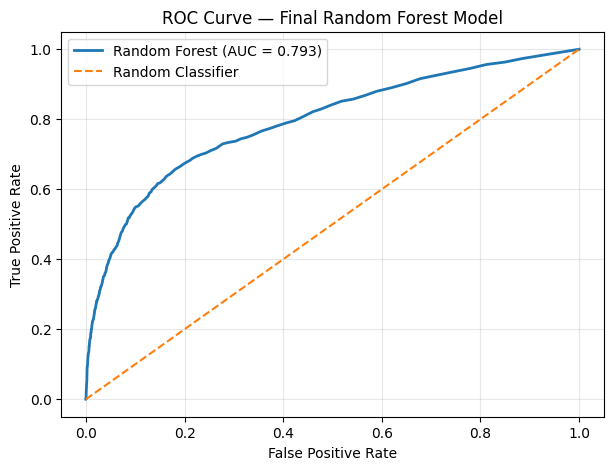

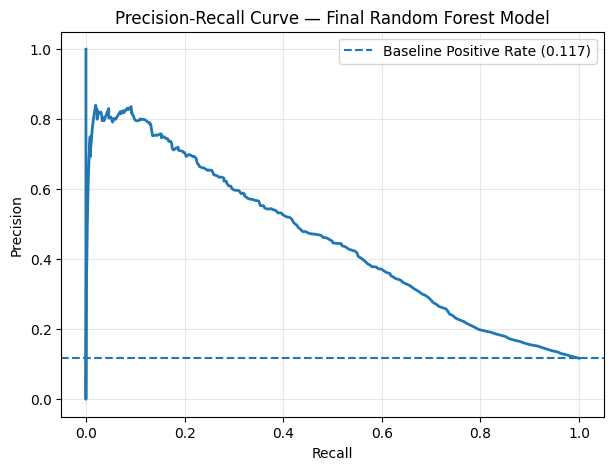

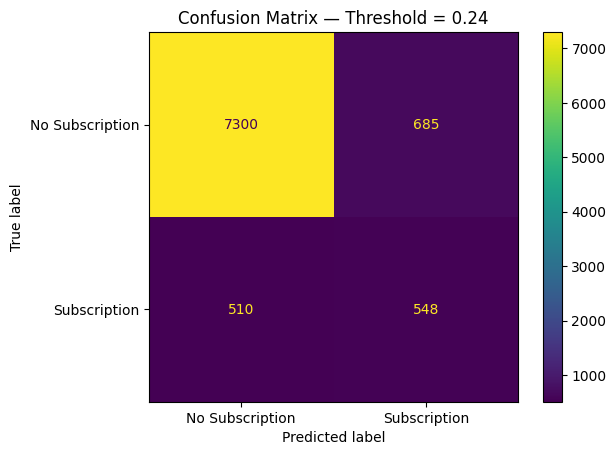

In [18]:
# ============================================================
# Final Model Performance Visualization
# ============================================================

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {test_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Random Forest Model")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# Precision-Recall curve
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2
)

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Baseline Positive Rate ({y_test.mean():.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Final Random Forest Model")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Subscription", "Subscription"]
).plot(
    values_format="d"
)

plt.title(
    f"Confusion Matrix — Threshold = {final_threshold:.2f}"
)

plt.show()

TOP 15 RANDOM FOREST FEATURES
-------------------------------------------------------


,Feature,Importance
0,balance,0.1684
1,age,0.1425
2,day,0.1271
3,campaign,0.0705
4,pdays,0.0436
5,contact_unknown,0.0397
6,poutcome_success,0.0363
7,housing_yes,0.0306
8,previous,0.0219
9,education_secondary,0.0185


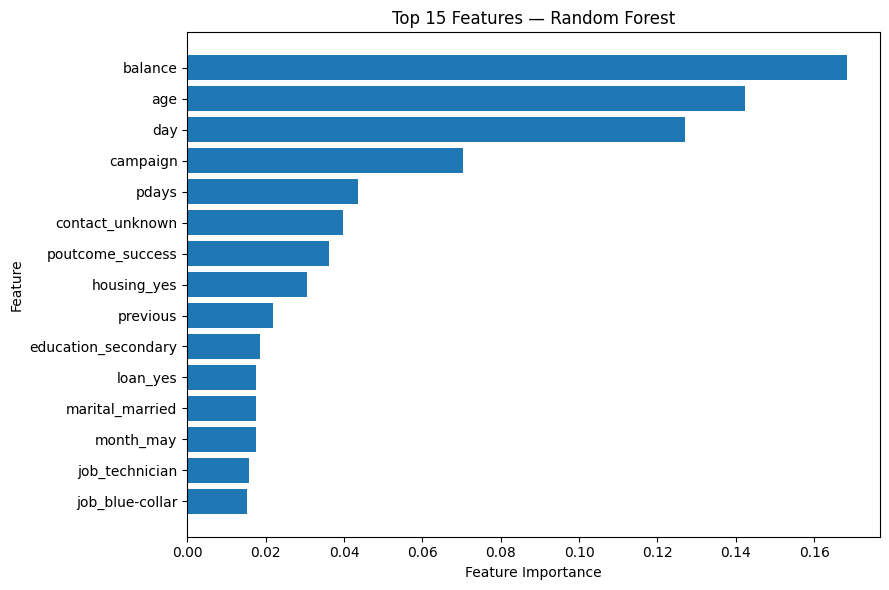

In [19]:
# ============================================================
# Random Forest — Feature Importance
# ============================================================

# Extract fitted preprocessing and Random Forest components
fitted_preprocessor = random_forest_model.named_steps["preprocessor"]
fitted_rf = random_forest_model.named_steps["classifier"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importances
feature_importances = fitted_rf.feature_importances_

# Create importance table
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

# Clean feature names for presentation
importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Sort from most important to least important
importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("TOP 15 RANDOM FOREST FEATURES")
print("-" * 55)

display(
    importance_df.head(15).style.format(
        {"Importance": "{:.4f}"}
    )
)

# Plot Top 15
top_features = importance_df.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Random Forest")

plt.tight_layout()
plt.show()

AGGREGATED FEATURE IMPORTANCE
-------------------------------------------------------


,Original_Feature,Importance
0,balance,0.1684
1,age,0.1425
2,day,0.1271
3,month,0.1100
4,job,0.0921
5,campaign,0.0705
6,poutcome,0.0514
7,contact,0.0499
8,pdays,0.0436
9,education,0.0395


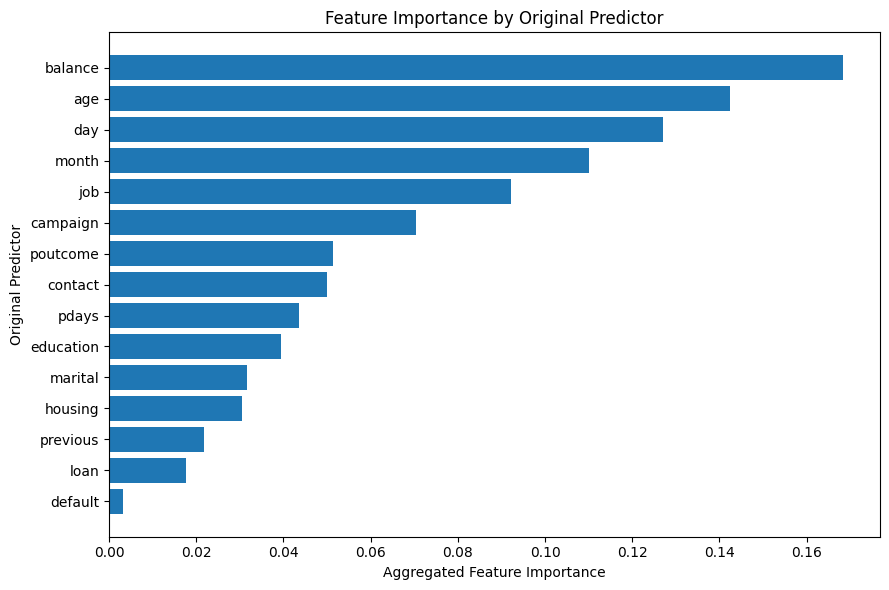

In [20]:
# ============================================================
# Aggregated Feature Importance — Original Variables
# ============================================================

# Map transformed features back to original variables
def get_original_feature(feature_name):

    # Numerical variables keep their original names
    if feature_name in numeric_features:
        return feature_name

    # Categorical dummy variables map back to original variable
    for col in categorical_features:
        if feature_name.startswith(col + "_"):
            return col

    return feature_name


importance_df["Original_Feature"] = (
    importance_df["Feature"].apply(get_original_feature)
)

# Sum importance across dummy variables belonging to
# the same original categorical feature
aggregated_importance = (
    importance_df
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("AGGREGATED FEATURE IMPORTANCE")
print("-" * 55)

display(
    aggregated_importance.style.format(
        {"Importance": "{:.4f}"}
    )
)

# Plot all 15 original predictors
plot_importance = aggregated_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_importance["Original_Feature"],
    plot_importance["Importance"]
)

plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Original Predictor")
plt.title("Feature Importance by Original Predictor")

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# Business Insights — Customer Segment Analysis
# ============================================================

# Create analysis dataset
insight_df = df_model.copy()

# Convert target to numeric
insight_df["subscribed"] = (
    insight_df["y"].map({"no": 0, "yes": 1})
)

# ------------------------------------------------------------
# 1. Balance groups
# ------------------------------------------------------------

insight_df["balance_group"] = pd.qcut(
    insight_df["balance"],
    q=4,
    duplicates="drop"
)

balance_analysis = (
    insight_df
    .groupby("balance_group", observed=True)["subscribed"]
    .agg(["count", "mean"])
    .reset_index()
)

balance_analysis["subscription_rate"] = (
    balance_analysis["mean"] * 100
)

# ------------------------------------------------------------
# 2. Age groups
# ------------------------------------------------------------

insight_df["age_group"] = pd.cut(
    insight_df["age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=[
        "≤30",
        "31–40",
        "41–50",
        "51–60",
        "60+"
    ]
)

age_analysis = (
    insight_df
    .groupby("age_group", observed=True)["subscribed"]
    .agg(["count", "mean"])
    .reset_index()
)

age_analysis["subscription_rate"] = (
    age_analysis["mean"] * 100
)

# ------------------------------------------------------------
# 3. Previous campaign outcome
# ------------------------------------------------------------

poutcome_analysis = (
    insight_df
    .groupby("poutcome")["subscribed"]
    .agg(["count", "mean"])
    .reset_index()
)

poutcome_analysis["subscription_rate"] = (
    poutcome_analysis["mean"] * 100
)

# ------------------------------------------------------------
# 4. Contact type
# ------------------------------------------------------------

contact_analysis = (
    insight_df
    .groupby("contact")["subscribed"]
    .agg(["count", "mean"])
    .reset_index()
)

contact_analysis["subscription_rate"] = (
    contact_analysis["mean"] * 100
)

# Display results
print("BALANCE SEGMENTS")
display(
    balance_analysis[
        ["balance_group", "count", "subscription_rate"]
    ].round(2)
)

print("\nAGE SEGMENTS")
display(
    age_analysis[
        ["age_group", "count", "subscription_rate"]
    ].round(2)
)

print("\nPREVIOUS CAMPAIGN OUTCOME")
display(
    poutcome_analysis[
        ["poutcome", "count", "subscription_rate"]
    ]
    .sort_values("subscription_rate", ascending=False)
    .round(2)
)

print("\nCONTACT TYPE")
display(
    contact_analysis[
        ["contact", "count", "subscription_rate"]
    ]
    .sort_values("subscription_rate", ascending=False)
    .round(2)
)

BALANCE SEGMENTS


,balance_group,count,subscription_rate
0,"(-8019.001, 72.0]",11317,7.24
1,"(72.0, 448.0]",11291,10.89
2,"(448.0, 1428.0]",11306,12.52
3,"(1428.0, 102127.0]",11297,16.15



AGE SEGMENTS


,age_group,count,subscription_rate
0,≤30,7030,16.29
1,31–40,17687,10.24
2,41–50,11239,9.07
3,51–60,8067,10.05
4,60+,1188,42.26



PREVIOUS CAMPAIGN OUTCOME


,poutcome,count,subscription_rate
2,success,1511,64.73
1,other,1840,16.68
0,failure,4901,12.61
3,unknown,36959,9.16



CONTACT TYPE


,contact,count,subscription_rate
0,cellular,29285,14.92
1,telephone,2906,13.42
2,unknown,13020,4.07


In [22]:
# ============================================================
# Final Project Summary
# ============================================================

print("=" * 70)
print("BANK MARKETING SUBSCRIPTION PREDICTION — PROJECT SUMMARY")
print("=" * 70)

print("\n1. DATASET")
print("-" * 40)
print(f"Observations: {len(df):,}")
print(f"Original variables: {df.shape[1]}")
print(f"Model predictors: {X_train.shape[1]}")
print(f"Positive class rate: {y.mean():.2%}")
print("Excluded leakage variable: duration")

print("\n2. MODEL DEVELOPMENT")
print("-" * 40)
print("Models compared:")
print("  • Logistic Regression")
print("  • Random Forest")
print("\nData split:")
print(f"  • Training:   {len(X_train):,}")
print(f"  • Validation: {len(X_val):,}")
print(f"  • Test:       {len(X_test):,}")

print("\n3. VALIDATION MODEL COMPARISON")
print("-" * 40)
display(model_comparison_display)

print("\nSelected model: Random Forest")
print(f"Selected threshold: {final_threshold:.4f}")

print("\n4. FINAL TEST PERFORMANCE")
print("-" * 40)
print(f"ROC-AUC:   {test_auc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")
print(f"Accuracy:  {test_accuracy:.4f}")

print("\n5. CONFUSION MATRIX")
print("-" * 40)
print(f"True Negatives:  {cm[0,0]:,}")
print(f"False Positives: {cm[0,1]:,}")
print(f"False Negatives: {cm[1,0]:,}")
print(f"True Positives:  {cm[1,1]:,}")

print("\n6. TOP PREDICTORS")
print("-" * 40)

for i, row in aggregated_importance.head(5).iterrows():
    print(
        f"{i+1}. {row['Original_Feature']}: "
        f"{row['Importance']:.4f}"
    )

print("\n7. KEY BUSINESS INSIGHTS")
print("-" * 40)

print(
    "• Subscription rate increased from 7.24% in the lowest "
    "balance quartile to 16.15% in the highest."
)

print(
    "• Customers aged 60+ showed the highest observed "
    "subscription rate (42.26%)."
)

print(
    "• Customers with a successful previous campaign outcome "
    "had a 64.73% observed subscription rate."
)

print(
    "• Cellular contacts showed a 14.92% subscription rate, "
    "compared with 4.07% for unknown contact type."
)

print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)

BANK MARKETING SUBSCRIPTION PREDICTION — PROJECT SUMMARY

1. DATASET
----------------------------------------
Observations: 45,211
Original variables: 17
Model predictors: 15
Positive class rate: 11.70%
Excluded leakage variable: duration

2. MODEL DEVELOPMENT
----------------------------------------
Models compared:
  • Logistic Regression
  • Random Forest

Data split:
  • Training:   27,126
  • Validation: 9,042
  • Test:       9,043

3. VALIDATION MODEL COMPARISON
----------------------------------------


,Model,ROC-AUC,Optimal Threshold,Precision,Recall,F1-score
0,Logistic Regression,0.7643,0.2061,0.4675,0.4282,0.4470
1,Random Forest,0.7813,0.2400,0.4382,0.4991,0.4666



Selected model: Random Forest
Selected threshold: 0.2400

4. FINAL TEST PERFORMANCE
----------------------------------------
ROC-AUC:   0.7932
Precision: 0.4444
Recall:    0.5180
F1-score:  0.4784
Accuracy:  0.8679

5. CONFUSION MATRIX
----------------------------------------
True Negatives:  7,300
False Positives: 685
False Negatives: 510
True Positives:  548

6. TOP PREDICTORS
----------------------------------------
1. balance: 0.1684
2. age: 0.1425
3. day: 0.1271
4. month: 0.1100
5. job: 0.0921

7. KEY BUSINESS INSIGHTS
----------------------------------------
• Subscription rate increased from 7.24% in the lowest balance quartile to 16.15% in the highest.
• Customers aged 60+ showed the highest observed subscription rate (42.26%).
• Customers with a successful previous campaign outcome had a 64.73% observed subscription rate.
• Cellular contacts showed a 14.92% subscription rate, compared with 4.07% for unknown contact type.

PROJECT COMPLETED SUCCESSFULLY
